In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle
import astropy.units as u
from astropy.io import fits
import os
from pathlib import Path
import time
import copy
from IPython.display import clear_output
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import skimage
from skimage.registration import phase_cross_correlation

import poppy
from poppy.poppy_core import PlaneType

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

from importlib import reload

import esc_fresnel

import esc_fresnel.utils as utils
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3, imshow
import esc_fresnel.esc_fresnel_subap as esc
import esc_fresnel.esc_optics as esc_optics



/home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
2025-03-27 08:54:15,041	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [12]:
wfe_dir = 'V20250325-cropped'
wfe_dir = 'V20250326-cropped'

dm_flat = utils.load_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_flat.fits')
dh_command = utils.load_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_dh_command_1e-8.fits')
# dh_command = utils.load_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_dh_command_1e-9.fits')
# dh_command = utils.load_fits(esc_fresnel.path/'wfe-maps'/wfe_dir/'dm_dh_command_5e-10.fits')

wfe_keys = [
    'm1',
    'm2',
    'm3', 
    'm4',
    'oap1',
    'fm1',
    'oap2',
    'oap3',
    'fsm',
    'fm2',
    'oap4',
    'oap5',
    'input_lp',
    'input_qwp',
    'oap6',
    'oap7',
    'oap9',
    'collimator',
    'filter',
    'output_qwp',
    'output_lp',
    'oap10',
]

wfes = {}
for optic in wfe_keys:
    wfe = poppy.FITSOpticalElement(
        opd=str(esc_fresnel.path/'wfe-maps'/wfe_dir/f'{optic}_opd.fits'), 
        opdunits='nanometers',
        transmission=str(esc_fresnel.path/'wfe-maps'/wfe_dir/f'{optic}_amp.fits'),
        name=f'{optic}_wfe',
        planetype=poppy.poppy_core.PlaneType.intermediate,
    )
    wfes[optic] = wfe

0


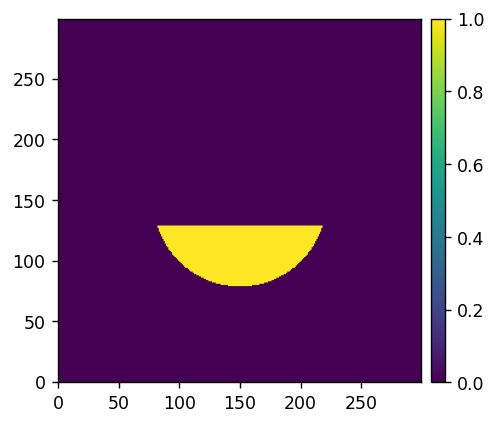

1


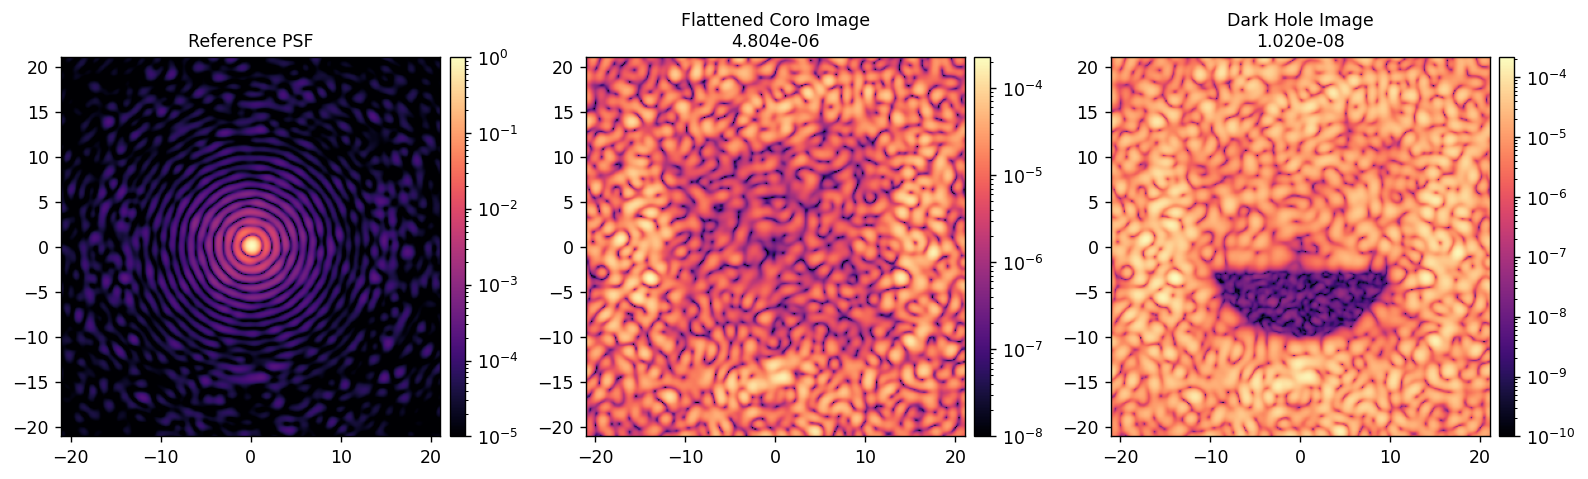

In [13]:
reload(esc)
reload(esc_optics)
M = esc.single(
    dm_ref=dm_flat,
)
M.wfes = wfes
M.npsf = 300

M.use_vortex = False
ref_psf = M.snap()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = True
coro_im_flat = M.snap()

M.set_dm(dh_command, channel=2)
coro_im_dh = M.snap()

iwa = 3
owa = 10
coro_mask = utils.create_annular_focal_plane_mask(
    M.npsf,
    M.camsci_pxscl_lamDc,
    irad=iwa, 
    orad=owa,
    edge=iwa,
    rotation=90,
)
imshow([coro_mask])

contrast_flat = utils.mean(coro_im_flat, coro_mask)
contrast_dh = utils.mean(coro_im_dh, coro_mask)

imshow(
    [ref_psf/M.Imax_ref, coro_im_flat, coro_im_dh],
    # [ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask],
    titles=[f'Reference PSF', 
            f'Flattened Coro Image\n{contrast_flat:.3e}', 
            f'Dark Hole Image\n{contrast_dh:.3e}'],
    norms=[LogNorm(vmin=1e-5), LogNorm(vmin=1e-8), LogNorm(vmin=1e-10)],
    pxscls=[M.camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
    wspace=0.3,
)

1


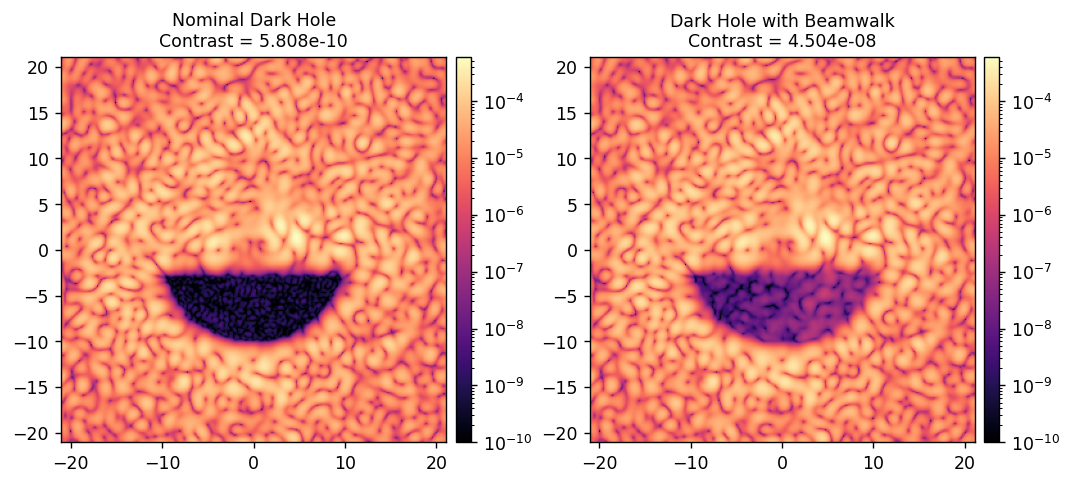

In [4]:
source_offset = np.array([-1, 1])
m4_fsm_ratio = 1/2

M.source_offset = (0, 0)
M.set_m4( [0,0] )
M.set_fsm( [0,0] )
M.reset_dm()
M.set_dm(dh_command, channel=3)
dh0 = M.snap()
contrast0 = xp.mean(dh0[coro_mask])

M.source_offset = source_offset
M.set_m4( -source_offset * m4_fsm_ratio )
M.set_fsm( -source_offset * (1 - m4_fsm_ratio) )
dh_with_beamwalk = M.snap()
contrast_with_beamwalk = xp.mean(dh_with_beamwalk[coro_mask])

imshow(
    [dh0, dh_with_beamwalk],
    titles=[f'Nominal Dark Hole\nContrast = {contrast0:.3e}', f'Dark Hole with Beamwalk\nContrast = {contrast_with_beamwalk:.3e}'],
    norms=[LogNorm(1e-10)]*2,
    cmaps=['magma']*2,
    pxscls=[M.camsci_pxscl_lamDc]*2,
)

3600
(3600, 2)
1


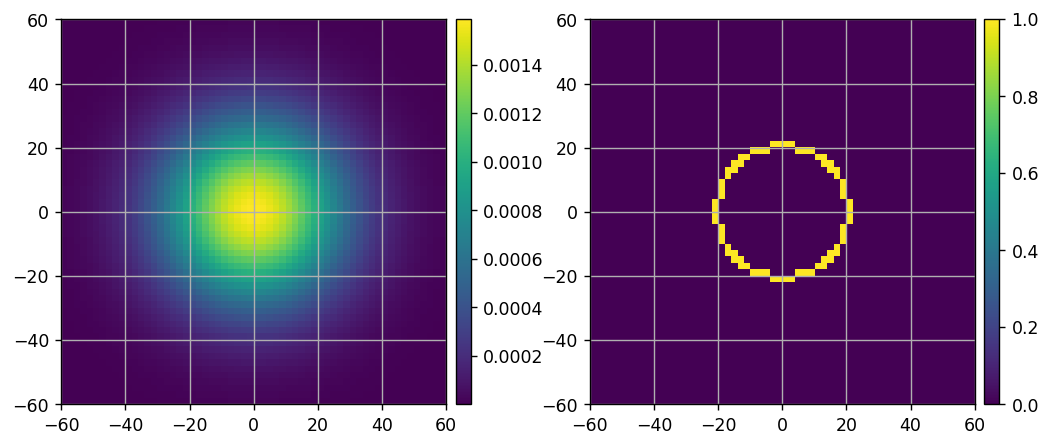

array(0.99462976)

In [5]:
jitter = 20*u.mas
pointing_sampling = jitter/10
Np = int(np.round( (6*jitter / pointing_sampling).decompose().value))
Nsamples = Np**2
print(Nsamples)

yc, xc = (xp.indices((Np, Np)) - Np//2 + 1/2)* pointing_sampling.to_value(u.mas)
rc = xp.sqrt(xc**2 + yc**2)
pdf_std = ( jitter.to_value(u.mas)-0.5 < rc ) * ( rc < jitter.to_value(u.mas)+1.5 )
pointing_samples = ensure_np_array ( xp.array([xc.flatten(), yc.flatten()]).T ) * u.mas
print(pointing_samples.shape)

amp = pointing_sampling.to_value(u.mas)**2 * 1/(2*xp.pi*jitter.to_value(u.mas)**2)
pointing_pdf = amp * xp.exp( -1/2 * ( (xc/jitter.to_value(u.mas))**2 + (yc/jitter.to_value(u.mas))**2 ) ) 
imshow(
    [pointing_pdf, pdf_std], 
    pxscls=2*[pointing_sampling.value], 
    grids=[1, 1],
)

xp.sum(pointing_pdf)

0


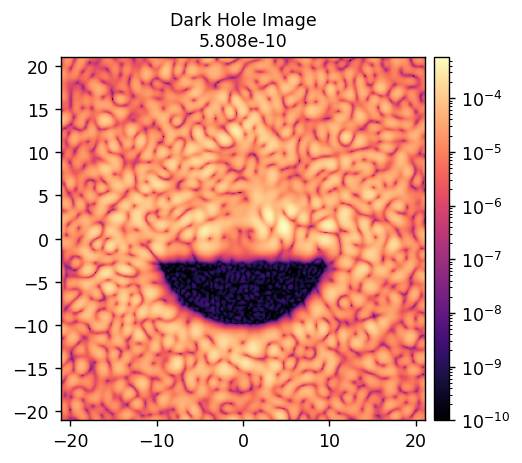

In [6]:
M.use_vortex = True
M.wfes = wfes
M.source_offset = (0, 0)
M.set_m4( [0,0] )
M.set_fsm( [0,0] )
M.reset_dm()
M.set_dm(dh_command)
nominal_dh = M.snap()

nominal_contrast = utils.mean(nominal_dh, coro_mask)

imshow(
    [nominal_dh],
    titles=[f'Dark Hole Image\n{nominal_contrast:.3e}'],
    norms=[LogNorm(1e-10)],
    pxscls=[M.camsci_pxscl_lamDc],
    cmaps=['magma'],
    # npix=[100]
)

In [7]:
%timeit M.snap()

321 ms ± 469 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [8]:
import time
import copy

m4_fsm_ratio = 1/2

quiet = 1
plot = 0
plot_all_wfes = 0

N_wfe_optics = len(wfes)
wfe_keys = list(wfes.keys())

contrasts = []
all_ims = []
total_im = 0.0

start = time.time()
for i in np.arange(Nsamples):
    # if i>10: break
    pointing = pointing_samples[i]
    pointing_lamD = (pointing / M.as_per_lamD).decompose().value
    amp = pointing_pdf.flatten()[i]
    if not quiet: 
        print(i) 
        print(pointing)
        print(pointing_lamD)
        print(amp)

    M.source_offset = pointing_lamD
    # M.set_fsm( -np.float64(pointing_lamD) )
    M.set_m4( -pointing_lamD * m4_fsm_ratio ) 
    M.set_fsm( -pointing_lamD * (1 - m4_fsm_ratio) ) 

    im = M.snap()
    contrast = utils.mean(im, coro_mask)
    total_im += amp * im

    contrasts.append(copy.copy(contrast))
    all_ims.append(copy.copy(im))

    if plot: 
        print(f"\tImage {i+1:d}/{Nsamples:d} computed in {time.time()-start:.3f}s")
        imshow(
            [im], 
            titles=[f'({pointing[0].value:.2f}, {pointing[1].value:.2f})\nContrast = {contrast:.3e}'], 
            norms=[LogNorm(1e-10)],
            cmaps=['magma'],
        )
        clear_output(wait=True)
    else:
        print(f"\tImage {i+1:d}/{Nsamples:d} computed in {time.time()-start:.3f}s", end='')
        print("\r", end="")

In [10]:
beamwalk_data = {
    'nominal_im':nominal_dh,
    'nominal_contrast':nominal_contrast,
    'pointing_sampling':pointing_sampling,
    'pointing_samples': pointing_samples, 
    'pointing_pdf':pointing_pdf,
    'm4_fsm_ratio':m4_fsm_ratio,
    'all_images':xp.array(all_ims),
    'coro_mask':coro_mask,
    'pxscl':M.camsci_pxscl_lamDc,
    'contrasts':xp.array(contrasts),
    'jitter_std':jitter,
}

utils.save_pickle(esc_fresnel.path/'data'/f'esc_beamwalk_data_{today}.pkl', beamwalk_data)



Saved data to:  /home/kianmilani/Projects/esc-fresnel/esc_fresnel/data/esc_beamwalk_data_20250327.pkl


In [14]:
5.093e-9 - 5.8e-10, 1.460e-8 - 1.020e-8

(4.513e-09, 4.4e-09)

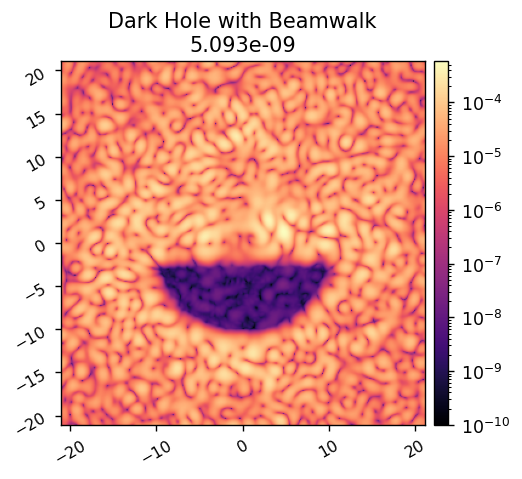

In [9]:
contrast_with_beamwalk = utils.mean(total_im, coro_mask)

imshow1(
    total_im, 
    f'Dark Hole with Beamwalk\n{contrast_with_beamwalk:.3e}', 
    lognorm=1, 
    pxscl=M.camsci_pxscl_lamDc, 
    vmin=1e-10, 
)

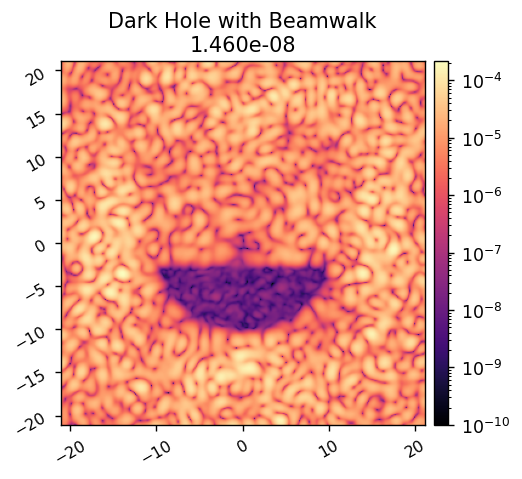

In [10]:
contrast_with_beamwalk = utils.mean(total_im, coro_mask)

imshow1(
    total_im, 
    f'Dark Hole with Beamwalk\n{contrast_with_beamwalk:.3e}', 
    lognorm=1, 
    pxscl=M.camsci_pxscl_lamDc, 
    vmin=1e-10, 
)

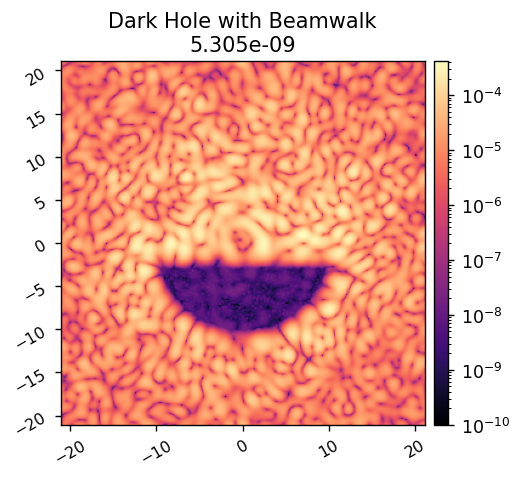

In [8]:
contrast_with_beamwalk = utils.mean(total_im, coro_mask)

imshow1(
    total_im, 
    f'Dark Hole with Beamwalk\n{contrast_with_beamwalk:.3e}', 
    lognorm=1, 
    pxscl=M.camsci_pxscl_lamDc, 
    vmin=1e-10, 
)

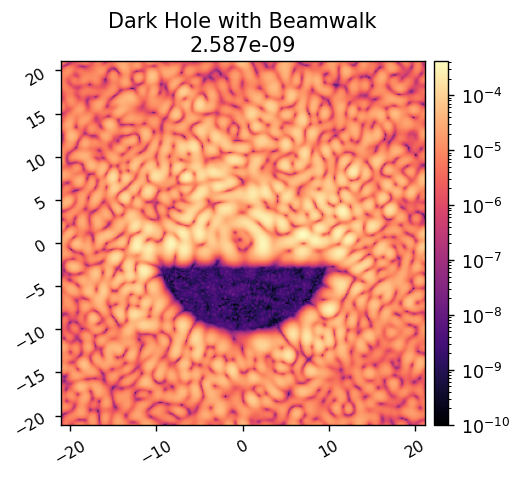

In [10]:
contrast_with_beamwalk = utils.mean(total_im, coro_mask)

imshow1(
    total_im,
    f'Dark Hole with Beamwalk\n{contrast_with_beamwalk:.3e}',
    lognorm=1,
    pxscl=M.camsci_pxscl_lamDc,
    vmin=1e-10, 
)

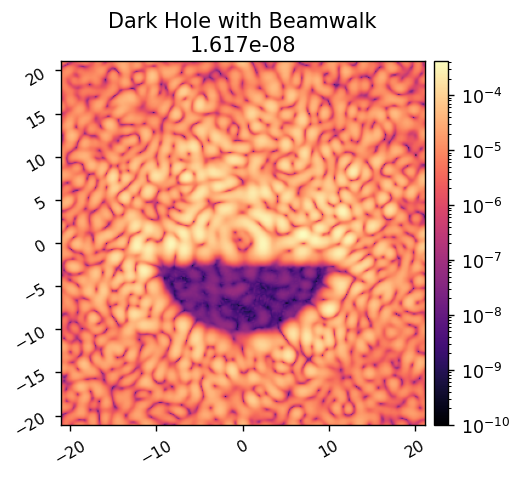

In [ ]:
contrast_with_beamwalk = utils.mean(total_im, coro_mask)

imshow1(
    total_im,
    f'Dark Hole with Beamwalk\n{contrast_with_beamwalk:.3e}',
    lognorm=1,
    pxscl=M.camsci_pxscl_lamDc,
    vmin=1e-10, 
)